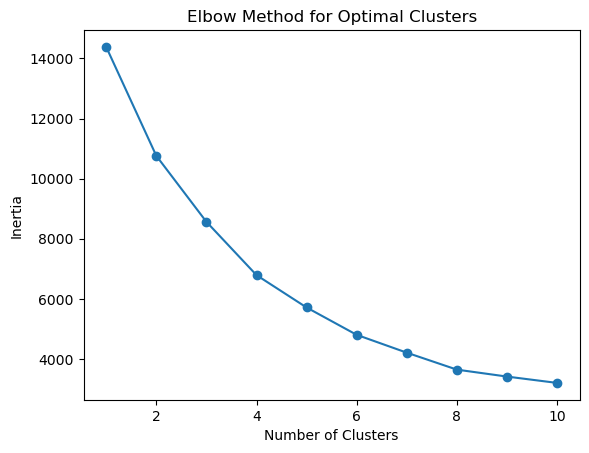

User_Segment
2    1671
1    1634
0    1489
Name: count, dtype: int64
              Genre_Exploration  Number_of_Audiobooks_Completed  \
User_Segment                                                      
0                      3.085964                       48.443922   
1                      4.250306                       47.057528   
2                      7.613405                       56.910233   

              Membership_Duration      Age_Group Gender Subscription_Type  
User_Segment                                                               
0                       16.294157  25 - 30 years   Male            Yearly  
1                       47.810894  25 - 30 years   Male           Monthly  
2                       24.168761  25 - 30 years   Male          Per-book  


ValueError: could not convert string to float: '25 - 30 years'

<Figure size 1000x600 with 0 Axes>

In [47]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_excel("Audible_Data (2).xlsx", sheet_name="DataSet")

# Select features for clustering
X_cluster = data[["Genre_Exploration", "Number_of_Audiobooks_Completed", "Membership_Duration"]]

# Standardize data (K-Means performs better with scaled data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Find optimal clusters using the Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

# Apply K-Means with chosen number of clusters (e.g., 3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data["User_Segment"] = kmeans.fit_predict(X_scaled)

# Display number of users in each segment
print(data["User_Segment"].value_counts())

# Analyze cluster characteristics
cluster_analysis = data.groupby("User_Segment").agg({
    "Genre_Exploration": "mean",
    "Number_of_Audiobooks_Completed": "mean",
    "Membership_Duration": "mean",
    "Age_Group": lambda x: x.mode()[0],
    "Gender": lambda x: x.mode()[0],
    "Subscription_Type": lambda x: x.mode()[0]
})

print(cluster_analysis)

# Visualize cluster characteristics
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_analysis, annot=True, cmap="YlGnBu")
plt.title("Cluster Characteristics")
plt.show()